# Loans at Risk: Capturing Default - EXPLORATORY DATA ANALYSIS

This notebook performs exploratory data analysis in two structured stages:

1. **Diagnostic validation** using the `clean` dataset.
2. **Decision-focused analysis** using the `feature_base` dataset.

The purpose is to:

- Validate outcome coherence and temporal structure.
- Define and confirm the modeling cohort.
- Examine submission-time feature behavior.
- Produce modeling directives for the next phase.

---

#### Notebook Structure

##### Imports & Setup
- Import required libraries and helper functions.
- Define project paths and initialize logging.
- Load `clean` and `feature_base` datasets.
- Confirm dataset alignment (shape and schema).

No data transformations are performed in this notebook.

---

#### Part 1 – Diagnostic Validation (`clean`)
Evaluates structural integrity and outcome behavior to confirm that the dataset is coherent and suitable for modeling.

---

#### Part 2 – Decision EDA (`feature_base`)
Analyzes submission-time features within the defined modeling boundary to assess signal quality, stability, and modeling implications.

In [1]:
import sys
from pathlib import Path

# -------------------------------
# Dynamically find project root by locating the 'data' folder
# -------------------------------
project_root = Path.cwd()
for parent in [project_root] + list(project_root.parents):
    if (parent / "data").exists():
        project_root = parent
        break

# Add src folder to sys.path so we can import custom Python modules
sys.path.append(str(project_root / "src"))

In [2]:
# -------------------------------
# Imports: libraries and custom functions
# -------------------------------

from datetime import datetime, timezone
from typing import Callable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.display import HTML
from ipywidgets import HBox, VBox, Output, Layout

# Custom functions from Python scripts package
from python.logging_utils import (
    log_messages,
    get_logger
)
from python.eda_utils import (
    build_terminal_cohort,
)

In [3]:
# ===============================
# Paths and run context
# ===============================

# Base logs folder
logs_root = project_root / "logs"
logs_root.mkdir(exist_ok=True)

# Log file
project_log_file = logs_root / "project.log"
project_log_file.touch(exist_ok=True)

# Add a clear visual separator for this run in the log
separator = "\n" + "="*60 + "\n"
run_header = f"NEW RUN: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')}"

log_messages(separator, str(project_log_file))
log_messages(run_header, str(project_log_file))
log_messages("=" * 60, str(project_log_file))

# Print immediately in the notebook which run is starting
print(run_header)

# Initialize lightweight logger for this notebook
log: Callable[[str], None] = get_logger(str(project_log_file))
log("EDA notebook initialized")
    

# -------------------------------------
# Inputs for this notebook (interim)
# -------------------------------------
clean_training_data_file = project_root / "data" / "interim" / "clean_loan_data_2007_2014.parquet"
clean_test_data_file = project_root / "data" / "interim" / "clean_loan_data_2015.parquet"

feature_base_training_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2007_2014.parquet"
feature_base_test_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2015.parquet"

NEW RUN: 2026-02-20 15:25:26


In [4]:
# Loading the dataframes for EDA
log("Loading clean training dataset")
df_clean_train = pd.read_parquet(clean_training_data_file)
log("Clean training dataset loaded")

log("Loading clean test dataset")
df_clean_test = pd.read_parquet(clean_test_data_file)
log("Clean test dataset loaded")

print("df_clean_train shape:", df_clean_train.shape)
print("df_clean_test shape:", df_clean_test.shape)

df_clean_train shape: (466285, 51)
df_clean_test shape: (421094, 51)


## Part 1 — Diagnostic Validation (`clean`)

This section evaluates outcome integrity, cohort definition, and structural stability using the `clean` dataset.

---

#### 1.1 Label integrity and outcome distribution
- Inspect normalized `loan_status` categories.
- Evaluate class balance across training (2007–2014) and test (2015).
- Identify temporal shifts in outcome composition.

---

#### 1.2 Cohort definition
- Assess suitability of a binary terminal cohort.
- Evaluate treatment of non-terminal statuses.
- Define the realized-outcome modeling population.

---

#### 1.3 Temporal outcome dynamics
- Compute default rate by year.
- Examine issuance volume by year.
- Identify maturation effects or structural breaks.

---

#### 1.4 Missingness and reporting stability
- Assess temporal missingness patterns in key balance variables.
- Evaluate potential reporting regime shifts.

---

#### 1.5 Structural boundary confirmation
- Confirm separation between submission-time features and post-submission variables.
- Validate economic coherence of outcome and cashflow variables.

---

#### 1.6 Diagnostic summary
Summarizes findings and formalizes the modeling cohort for Part 2.

In [5]:
# -------------------------------
# Add issue_year for vintage diagnostics (train + test)
# -------------------------------

df_clean_train_with_year = df_clean_train.copy()
df_clean_test_with_year = df_clean_test.copy()

df_clean_train_with_year["issue_year"] = (
    pd.to_datetime(
        df_clean_train_with_year["issue_d"],
        errors="coerce"
    ).dt.year
)

df_clean_test_with_year["issue_year"] = (
    pd.to_datetime(
        df_clean_test_with_year["issue_d"],
        errors="coerce"
    ).dt.year
)


In [6]:
# -------------------------------
# Loan status by vintage (train)
# -------------------------------

year_status_table_train = pd.crosstab(
    df_clean_train_with_year["issue_year"],
    df_clean_train_with_year["loan_status"],
    dropna=False
)

year_status_table_train


loan_status,charged_off,current,default,does_not_meet_the_credit_policy._status:charged_off,does_not_meet_the_credit_policy._status:fully_paid,fully_paid,in_grace_period,issued,late_(16-30_days),late_(31-120_days)
issue_year,,,,,,,,,,
2007,45,0,0,113,239,206,0,0,0,0
2008,247,0,0,249,582,1315,0,0,0,0
2009,594,0,0,129,436,4122,0,0,0,0
2010,1483,7,1,270,731,10038,0,0,2,5
2011,3205,1953,8,0,0,16470,28,0,11,46
2012,8084,3444,28,0,0,41479,83,0,27,222
2013,14836,60264,182,0,0,56396,977,0,320,1780
2014,13981,158558,613,0,0,54713,2058,0,858,4847


In [7]:
# -------------------------------
# Loan status by vintage (test)
# -------------------------------

year_status_table_test = pd.crosstab(
    df_clean_test_with_year["issue_year"],
    df_clean_test_with_year["loan_status"],
    dropna=False
)

year_status_table_test


loan_status,charged_off,current,default,does_not_meet_the_credit_policy._status:charged_off,does_not_meet_the_credit_policy._status:fully_paid,fully_paid,in_grace_period,issued,late_(16-30_days),late_(31-120_days)
issue_year,,,,,,,,,,
2015,2773,377553,387,0,0,22984,3107,8460,1139,4691


#### Outcome distribution by vintage

Outcome composition varies materially across issuance years.

- Early vintages (2007–2012) are predominantly composed of terminal outcomes, reflecting full maturation.
- Later vintages (2013–2014) exhibit a high concentration of non-terminal loans (`current`, `late`), driven by incomplete outcome realization.
- The 2015 split is heavily censored and contains a substantial share of ongoing loans.

These patterns indicate that aggregate class balance must be interpreted in a temporal context. Apparent dominance of `current` status is attributable to maturation dynamics rather than label inconsistency.

Moving forward, realized-outcome restriction is required to ensure label certainty and avoid censoring bias.

In [8]:
# -------------------------------
# Terminal cohort definition (realized outcomes only)
# -------------------------------

terminal_statuses_final = [
    "fully_paid",
    "charged_off",
    "default",
    "does_not_meet_the_credit_policy._status:charged_off",
    "does_not_meet_the_credit_policy._status:fully_paid",
]

positive_statuses = [
    "charged_off",
    "default",
    "does_not_meet_the_credit_policy._status:charged_off",
]


In [9]:
# -------------------------------
# Build terminal cohort with binary target (train + test)
# -------------------------------

df_clean_train_terminal = build_terminal_cohort(
    df_clean_train_with_year,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log_file=str(project_log_file),
)

df_clean_test_terminal = build_terminal_cohort(
    df_clean_test_with_year,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log_file=str(project_log_file),
)


In [64]:
# -------------------------------
# Terminal cohort summary (train)
# -------------------------------

terminal_distribution_train = (
    df_clean_train_terminal["loan_status"]
    .value_counts(dropna=False)
    .to_frame(name="count")
)

terminal_distribution_train["percentage"] = (
    terminal_distribution_train["count"]
    / terminal_distribution_train["count"].sum()
    * 100
).round(2)

default_rate_train_percent = round(
    float(df_clean_train_terminal["target_default"].mean() * 100),
    2
)

terminal_distribution_train.loc["__default_rate_percent__"] = {
    "count": int(df_clean_train_terminal["target_default"].sum()),
    "percentage": default_rate_train_percent,
}

display(terminal_distribution_train)

# -------------------------------
# Terminal cohort summary (test)
# -------------------------------

terminal_distribution_test = (
    df_clean_test_terminal["loan_status"]
    .value_counts(dropna=False)
    .to_frame(name="count")
)

terminal_distribution_test["percentage"] = (
    terminal_distribution_test["count"]
    / terminal_distribution_test["count"].sum()
    * 100
).round(2)

default_rate_test_percent = round(
    float(df_clean_test_terminal["target_default"].mean() * 100),
    2
)

terminal_distribution_test.loc["__default_rate_percent__"] = {
    "count": int(df_clean_test_terminal["target_default"].sum()),
    "percentage": default_rate_test_percent,
}

display(terminal_distribution_test)


,count,percentage
loan_status,,
fully_paid,184739,80.04
charged_off,42475,18.40
does_not_meet_the_credit_policy._status:fully_paid,1988,0.86
default,832,0.36
does_not_meet_the_credit_policy._status:charged_off,761,0.33
current,0,0.00
in_grace_period,0,0.00
issued,0,0.00
late_(16-30_days),0,0.00


,count,percentage
loan_status,,
fully_paid,22984,87.91
charged_off,2773,10.61
default,387,1.48
current,0,0.00
does_not_meet_the_credit_policy._status:charged_off,0,0.00
does_not_meet_the_credit_policy._status:fully_paid,0,0.00
in_grace_period,0,0.00
issued,0,0.00
late_(16-30_days),0,0.00


#### Realized-outcome cohort definition

Restricting the dataset to terminal outcomes produces a stable and interpretable binary modeling cohort.

- Non-terminal statuses (`current`, `late`, `in_grace_period`, `issued`) are excluded to eliminate censoring risk.
- Policy-flagged terminal categories are economically consistent with their respective primary classes and are collapsed into `charged_off` and `fully_paid`.
- Within the realized terminal cohort:
  - Train set default rate ≈ **19%** across ~230k observations.
  - Test set default rate ≈ **12%** across ~26k observations.

The lower default rate in the test split reflects vintage and macroeconomic differences rather than structural inconsistencies in labeling.
This cohort provides a coherent and economically interpretable modeling population with sufficient volume and usable class balance in both splits.
Moving forward, all diagnostic and validation analyses are conducted within this realized-outcome boundary.

In [ ]:
# ----------------------------------------------------------------
# Column groupings (clean dataset)
# Purpose: structured validation + leakage boundary control
# ----------------------------------------------------------------

# Target (label only)
target_columns = [
    "loan_status",
]

# Submission-time application inputs
application_input_columns = [
    "annual_inc",
    "dti",
    "home_ownership",
    "emp_length_years",
    "loan_amnt",
    "term_months",
    "purpose",
]

# Credit bureau snapshot at submission-time
credit_snapshot_columns = [
    "earliest_cr_line",
    "open_acc",
    "total_acc",
    "inq_last_6mths",
    "delinq_2yrs",
    "pub_rec",
    "collections_12_mths_ex_med",
    "revol_bal",
    "revol_util",
    "acc_now_delinq",
    "tot_cur_bal",
    "tot_coll_amt",
    "total_rev_hi_lim",
]

# Credit timing / recency signals (submission-time; null often means "no prior event")
credit_timing_columns = [
    "mths_since_last_delinq",
    "mths_since_last_major_derog",
    "mths_since_last_record",
    'has_mths_since_last_delinq', 
    'has_mths_since_last_major_derog', 
    'has_mths_since_last_record',
]

# Platform / underwriting signals (benchmark-only; excluded from modeling)
benchmark_platform_signal_columns = [
    "grade",
    "sub_grade",
    "int_rate",
    "installment",
    "verification_status",
    "initial_list_status",
    "pymnt_plan",
]

# Post-submission timeline markers (validation-only; excluded from modeling)
benchmark_timeline_columns = [
    "issue_d",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d",
]

# Post-origination cashflows and balances (validation-only; excluded from modeling)
benchmark_cashflow_columns = [
    "funded_amnt",
    "funded_amnt_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "out_prncp",
    "out_prncp_inv",
    "last_pymnt_amnt",
]

structural_columns = [
    "row_id",
]

# Combined list for coverage checks
all_grouped_columns = (
    target_columns
    + application_input_columns
    + credit_snapshot_columns
    + credit_timing_columns
    + benchmark_platform_signal_columns
    + benchmark_timeline_columns
    + benchmark_cashflow_columns
    + structural_columns
)

In [59]:
# -----------------------------------------------
# Coverage and overlap checks for train
# -----------------------------------------------

duplicate_grouped_columns_train = sorted({col for col in all_grouped_columns if all_grouped_columns.count(col) > 1})
unclassified_columns_train = sorted([col for col in df_clean_train.columns if col not in all_grouped_columns])
missing_group_columns_train = sorted([col for col in all_grouped_columns if col not in df_clean_train.columns])

print("Clean training dataset column grouping checks:")
print("Duplicate columns across groups:", duplicate_grouped_columns_train)
print("Unclassified columns (present in df, not grouped):", unclassified_columns_train)
print("Grouped columns missing from df:", missing_group_columns_train)
print()

# -----------------------------------------------
# Coverage and overlap checks for test
# -----------------------------------------------

duplicate_grouped_columns_test = sorted({col for col in all_grouped_columns if all_grouped_columns.count(col) > 1})
unclassified_columns_test = sorted([col for col in df_clean_test.columns if col not in all_grouped_columns])
missing_group_columns_test = sorted([col for col in all_grouped_columns if col not in df_clean_test.columns])

print()
print("Clean test dataset column grouping checks:")
print("Duplicate columns across groups:", duplicate_grouped_columns_test)
print("Unclassified columns (present in df, not grouped):", unclassified_columns_test)
print("Grouped columns missing from df:", missing_group_columns_test)

Clean training dataset column grouping checks:
Duplicate columns across groups: []
Unclassified columns (present in df, not grouped): []
Grouped columns missing from df: []


Clean test dataset column grouping checks:
Duplicate columns across groups: []
Unclassified columns (present in df, not grouped): []
Grouped columns missing from df: []


#### Reporting stability assessment

Balance-related credit variables (`tot_coll_amt`, `tot_cur_bal`, `total_rev_hi_lim`) exhibit structured temporal missingness.

Training split:
- Early vintages (2007–2011) show complete absence of these fields.
- 2012 represents a transition year with partial reporting.
- From 2013 onward, reporting is complete and stable.
- Overall missingness in the training set is approximately 15%.

Test split:
- 2015 shows full reporting with 0% missingness across all three variables.

The missingness pattern is therefore time-dependent rather than random. It reflects a reporting regime shift in the historical data rather than data corruption.
Observed default rates differ between missing and non-missing groups in the training split, but this difference aligns with vintage structure rather than borrower-level behavior.
Moving forward, these variables remain valid submission-time features but require regime-aware handling to prevent unintended temporal bias during modeling and validation.

In [13]:
# -------------------------------
# Benchmark cashflow sanity check
# (train terminal cohort)
# -------------------------------

cashflow_summary_by_status = (
    df_clean_train_terminal
    .groupby("loan_status")[benchmark_cashflow_columns]
    .mean()
    .round(2)
)

cashflow_summary_by_status

,funded_amnt,funded_amnt_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,out_prncp,out_prncp_inv,last_pymnt_amnt
loan_status,,,,,,,,,,,,
charged_off,14470.24,14342.34,6657.34,6591.33,3484.71,2243.58,2.53,926.52,96.19,0.00,0.00,454.44
default,15284.89,15279.97,7782.17,7778.85,4755.83,3023.98,2.36,0.00,0.00,10529.06,10526.19,477.22
does_not_meet_the_credit_policy._status:charged_off,9248.13,5807.00,4803.72,3077.12,2880.66,1338.83,5.23,579.00,122.19,0.00,0.00,305.50
does_not_meet_the_credit_policy._status:fully_paid,8679.38,6411.14,10536.21,7804.20,8679.38,1854.18,2.66,0.00,0.00,0.00,0.00,2178.94
fully_paid,13169.99,13072.61,15209.87,15091.93,13158.29,2051.21,0.37,0.00,0.00,0.00,0.00,7165.94


In [34]:
# -------------------------------
# Benchmark cashflow sanity check
# (test terminal cohort)
# -------------------------------

cashflow_summary_by_status = (
    df_clean_test_terminal
    .groupby("loan_status")[benchmark_cashflow_columns]
    .mean()
    .round(2)
)

cashflow_summary_by_status

,funded_amnt,funded_amnt_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,out_prncp,out_prncp_inv,last_pymnt_amnt
loan_status,,,,,,,,,,,,
charged_off,15131.22,15126.88,1962.42,1961.80,900.98,716.31,1.44,343.69,54.98,0.00,0.00,458.55
default,14998.13,14993.41,2004.71,2004.10,1111.51,892.94,0.26,0.00,0.00,13886.62,13882.22,443.24
fully_paid,14406.98,14402.75,15000.28,14995.92,14293.82,706.37,0.09,0.00,0.00,0.00,0.00,12627.47


#### Structural boundary confirmation

Post-origination benchmark variables behave consistently with observed outcomes in both training and test splits.

- Cashflow variables (repayments, recoveries, outstanding principal) align economically with loan status in both datasets.
- Platform-assigned risk signals (`grade`, `sub_grade`, `int_rate`) show a clear and increasing relationship with realized default rates across splits.
- Verification status exhibits higher default rates for verified loans, reflecting risk-based verification practices rather than label inconsistency.
- No contradictions between outcome labels and realized payment behavior were identified.

These findings confirm that the dataset is internally coherent and that post-origination and underwriting variables are clearly distinguishable from submission-time modeling features.
Moving forward, benchmark variables remain excluded from training and serve strictly as validation anchors.

In [ ]:
# -------------------------------
# Default rate by grade (train terminal cohort)
# -------------------------------

default_rate_by_grade_train = (
    df_clean_train_terminal
    .groupby("grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

display(default_rate_by_grade_train)

# -------------------------------
# Default rate by grade (test terminal cohort)
# -------------------------------

default_rate_by_grade_test = (
    df_clean_test_terminal
    .groupby("grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

display(default_rate_by_grade_test)

,default_rate_percent
grade,
a,6.56
b,13.30
c,21.03
d,27.65
e,35.40
f,40.82
g,43.91


,default_rate_percent
grade,
a,3.21
b,6.86
c,10.71
d,17.57
e,20.79
f,26.70
g,23.83


In [48]:
# -------------------------------
# Default rate by sub_grade (train terminal cohort)
# -------------------------------

default_rate_by_sub_grade_train = (
    df_clean_train_terminal
    .groupby("sub_grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

default_rate_by_sub_grade_train

,default_rate_percent
sub_grade,
a1,3.29
a2,4.81
a3,5.87
a4,7.40
a5,8.74
b1,10.72
b2,11.55
b3,13.09
b4,14.65


In [51]:
# -------------------------------
# Default rate by sub_grade (test terminal cohort)
# -------------------------------

default_rate_by_sub_grade_test = (
    df_clean_test_terminal
    .groupby("sub_grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

default_rate_by_sub_grade_test

,default_rate_percent
sub_grade,
a1,0.25
a2,2.20
a3,2.63
a4,3.62
a5,4.67
b1,5.69
b2,5.18
b3,6.80
b4,7.62


In [36]:
# -------------------------------
# Create interest rate deciles (train terminal cohort)
# -------------------------------

df_clean_train_terminal = df_clean_train_terminal.copy()

df_clean_train_terminal["int_rate_decile"] = pd.qcut(
    df_clean_train_terminal["int_rate"],
    q=10,
    duplicates="drop"
)

# -------------------------------
# Create interest rate deciles (test terminal cohort)
# -------------------------------

df_clean_test_terminal = df_clean_test_terminal.copy()

df_clean_test_terminal["int_rate_decile"] = pd.qcut(
    df_clean_test_terminal["int_rate"],
    q=10,
    duplicates="drop"
)

In [57]:
# -------------------------------
# Default rate by interest rate decile (train)
# -------------------------------

default_rate_by_int_rate_decile_train = (
    df_clean_train_terminal
    .groupby("int_rate_decile")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
)

display(default_rate_by_int_rate_decile_train)

# -------------------------------
# Default rate by interest rate decile (test)
# -------------------------------

default_rate_by_int_rate_decile_test = (
    df_clean_test_terminal
    .groupby("int_rate_decile")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
)

display(default_rate_by_int_rate_decile_test)

,default_rate_percent
int_rate_decile,
"(5.419, 7.9]",5.72
"(7.9, 9.91]",9.58
"(9.91, 11.14]",11.63
"(11.14, 12.49]",14.22
"(12.49, 13.65]",16.65
"(13.65, 14.49]",18.78
"(14.49, 15.8]",22.20
"(15.8, 17.57]",26.52
"(17.57, 19.52]",29.64


,default_rate_percent
int_rate_decile,
"(5.319, 7.89]",3.07
"(7.89, 9.49]",5.33
"(9.49, 11.44]",7.20
"(11.44, 12.29]",8.64
"(12.29, 13.33]",10.35
"(13.33, 14.48]",11.12
"(14.48, 15.99]",14.35
"(15.99, 17.57]",17.90
"(17.57, 19.52]",18.71


In [ ]:
# Default rate by interest rate decile (train)
default_rate_by_int_rate_decile_train_display = (
    default_rate_by_int_rate_decile_train
    .reset_index()
    .rename(columns={"int_rate_decile": "int_rate_decile_range"})
)

display(default_rate_by_int_rate_decile_train_display)

# Default rate by interest rate decile (test)
default_rate_by_int_rate_decile_test_display = (
    default_rate_by_int_rate_decile_test
    .reset_index()
    .rename(columns={"int_rate_decile": "int_rate_decile_range"})
)

display(default_rate_by_int_rate_decile_test_display)

,int_rate_decile_range,default_rate_percent
0,"(5.419, 7.9]",5.72
1,"(7.9, 9.91]",9.58
2,"(9.91, 11.14]",11.63
3,"(11.14, 12.49]",14.22
4,"(12.49, 13.65]",16.65
5,"(13.65, 14.49]",18.78
6,"(14.49, 15.8]",22.20
7,"(15.8, 17.57]",26.52
8,"(17.57, 19.52]",29.64
9,"(19.52, 26.06]",38.31


,int_rate_decile_range,default_rate_percent
0,"(5.319, 7.89]",3.07
1,"(7.89, 9.49]",5.33
2,"(9.49, 11.44]",7.20
3,"(11.44, 12.29]",8.64
4,"(12.29, 13.33]",10.35
5,"(13.33, 14.48]",11.12
6,"(14.48, 15.99]",14.35
7,"(15.99, 17.57]",17.90
8,"(17.57, 19.52]",18.71
9,"(19.52, 28.99]",25.50


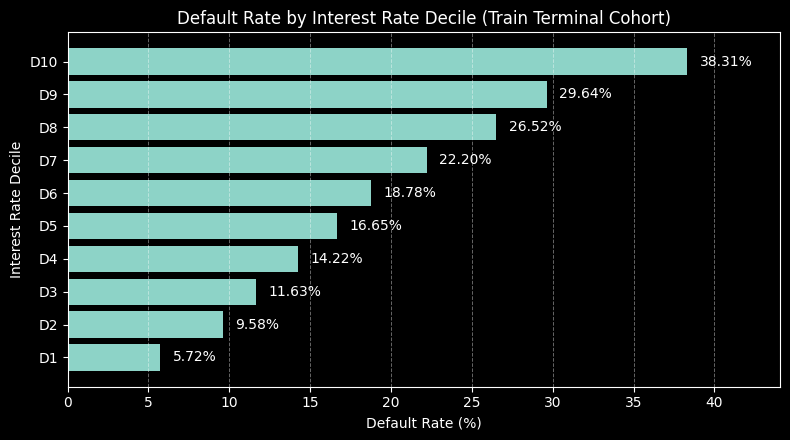

In [ ]:
# -------------------------------
# Default rate by interest-rate decile (hierarchy-first plot)
# -------------------------------

plot_dataframe = default_rate_by_int_rate_decile_train.copy()
plot_dataframe = plot_dataframe.reset_index(drop=False)
plot_dataframe["decile"] = [f"D{i+1}" for i in range(len(plot_dataframe))]

values = plot_dataframe["default_rate_percent"].tolist()
labels = plot_dataframe["decile"].tolist()

plt.figure(figsize=(8, 4.5))
bars = plt.barh(labels, values)

plt.xlabel("Default Rate (%)")
plt.ylabel("Interest Rate Decile")
plt.title("Default Rate by Interest Rate Decile (Train Terminal Cohort)")

plt.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
plt.xlim(0, max(values) * 1.15)

# Value labels at bar ends (instant readability)
for bar, value in zip(bars, values):
    plt.text(
        value + (max(values) * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

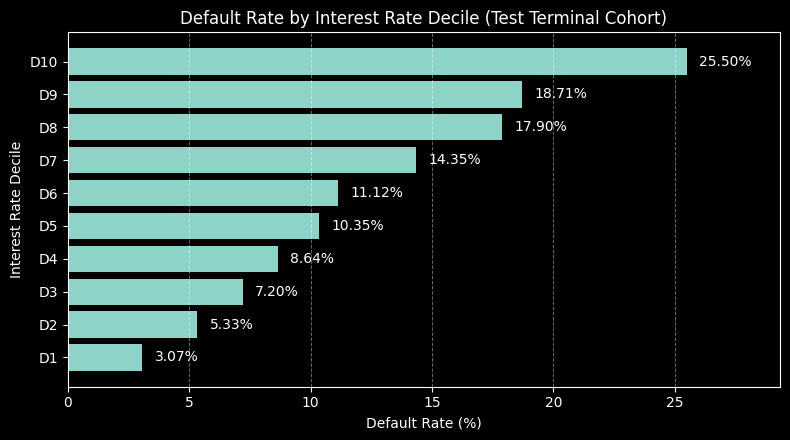

In [44]:
# -------------------------------
# Default rate by interest-rate decile (hierarchy-first plot)
# -------------------------------

plot_dataframe = default_rate_by_int_rate_decile_test.copy()
plot_dataframe = plot_dataframe.reset_index(drop=False)
plot_dataframe["decile"] = [f"D{i+1}" for i in range(len(plot_dataframe))]

values = plot_dataframe["default_rate_percent"].tolist()
labels = plot_dataframe["decile"].tolist()

plt.figure(figsize=(8, 4.5))
bars = plt.barh(labels, values)

plt.xlabel("Default Rate (%)")
plt.ylabel("Interest Rate Decile")
plt.title("Default Rate by Interest Rate Decile (Test Terminal Cohort)")

plt.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
plt.xlim(0, max(values) * 1.15)

# Value labels at bar ends (instant readability)
for bar, value in zip(bars, values):
    plt.text(
        value + (max(values) * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# Default rate by verification_status (train / test)
# -----------------------------------------------------------

default_rate_by_verification_train = (
    df_clean_train_terminal
    .groupby("verification_status")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_values("default_rate_percent")
)

display(default_rate_by_verification_train)

default_rate_by_verification_test = (
    df_clean_test_terminal
    .groupby("verification_status")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_values("default_rate_percent")
)

display(default_rate_by_verification_test)

,default_rate_percent
verification_status,
not_verified,15.19
source_verified,20.24
verified,21.94


,default_rate_percent
verification_status,
not_verified,9.55
source_verified,12.44
verified,13.79


#### Platform signal validation

The platform’s risk and pricing variables behave consistently with actual loan outcomes in both training and test splits.

- Default rates increase steadily from grade A to grade G in both datasets. Higher grades clearly correspond to higher realized default rates.
- Within each grade, sub-grades generally follow the same stepwise pattern, with risk increasing incrementally. Minor irregularities in some higher-risk buckets are attributable to smaller sample sizes.
- When loans are grouped by interest rate deciles, default rates rise consistently across rate buckets in both splits. Higher interest rates are associated with higher realized default rates.
- At first glance, `verification_status` appears counterintuitive: loans marked as "verified" show higher default rates than "not_verified" loans. However, this reflects risk-based verification rather than a protective effect. Higher-risk borrowers are more likely to be verified by the platform, so verification is applied more frequently to already riskier loans. The elevated default rate therefore reflects borrower risk, not the impact of verification itself.

Overall, the platform’s grading and pricing structure align with realized outcomes across both splits. No structural inconsistencies were identified.
These variables remain excluded from the modeling feature set, but they serve as important benchmark anchors when evaluating model performance later.

In [ ]:
# -------------------------------
# Overall missingness (train / test clean)
# -------------------------------

reporting_columns = [
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
]

#  Overall missingness for clean training dataset
missingness_overall_train = (
    df_clean_train_with_year[reporting_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="missing_percent")
)

display(missingness_overall_train)

# Overall missingness for clean test dataset
missingness_overall_test = (
    df_clean_test_with_year[reporting_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="missing_percent")
)

display(missingness_overall_test)

,missing_percent
tot_coll_amt,15.07
tot_cur_bal,15.07
total_rev_hi_lim,15.07


,missing_percent
tot_coll_amt,0.0
tot_cur_bal,0.0
total_rev_hi_lim,0.0


In [61]:
# -------------------------------
# Missingness by issue_year (train clean)
# -------------------------------

# Missingness by issue_year (train clean)
missingness_by_year_train = (
    df_clean_train_with_year
    .groupby("issue_year")[reporting_columns]
    .apply(lambda dataframe: dataframe.isna().mean() * 100)
    .round(2)
)

display(missingness_by_year_train)

# Missingness by issue_year (test clean)
missingness_by_year_test = (
    df_clean_test_with_year
    .groupby("issue_year")[reporting_columns]
    .apply(lambda dataframe: dataframe.isna().mean() * 100)
    .round(2)
)

display(missingness_by_year_test)

,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
issue_year,,,
2007,100.00,100.00,100.00
2008,100.00,100.00,100.00
2009,100.00,100.00,100.00
2010,100.00,100.00,100.00
2011,100.00,100.00,100.00
2012,51.98,51.98,51.98
2013,0.00,0.00,0.00
2014,0.00,0.00,0.00


,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
issue_year,,,
2015,0.0,0.0,0.0


#### Reporting stability assessment

Three credit balance variables (`tot_coll_amt`, `tot_cur_bal`, `total_rev_hi_lim`) exhibit identical missingness patterns across splits.

Training split:
- Loans issued between 2007–2011 show complete absence of these fields.
- 2012 represents a transition year with partial reporting.
- From 2013 onward, reporting is complete.
- Overall missingness (~15%) reflects the share of early vintages rather than borrower-level behavior.

Test split:
- 2015 shows full reporting with 0% missingness across all three variables.

The synchronized pattern across all three variables indicates a reporting regime change rather than random missingness or data corruption.
Observed differences in default rates between missing and non-missing groups in the training split align with vintage structure, not intrinsic borrower characteristics.
These variables remain structurally valid submission-time features but require awareness of their time-dependent availability in subsequent modeling and validation design.

In [30]:
# -------------------------------
# Missingness indicator (train terminal cohort)
# -------------------------------

df_clean_train_terminal = df_clean_train_terminal.copy()

df_clean_train_terminal["tot_cur_bal_missing"] = (
    df_clean_train_terminal["tot_cur_bal"].isna().astype(int)
)

df_clean_train_terminal["tot_coll_amt_missing"] = (
    df_clean_train_terminal["tot_coll_amt"].isna().astype(int)
)

df_clean_train_terminal["total_rev_hi_lim_missing"] = (
    df_clean_train_terminal["total_rev_hi_lim"].isna().astype(int)
)

In [ ]:
# -------------------------------
# Default rate by missingness train terminal cohort
# -------------------------------

for column in [
    "tot_cur_bal_missing",
    "tot_coll_amt_missing",
    "total_rev_hi_lim_missing",
]:
    result = (
        df_clean_train_terminal
        .groupby(column)["target_default"]
        .mean()
        .mul(100)
        .round(2)
        .to_frame(name="default_rate_percent")
    )
    
    print(f"\nDefault rate by {column}:")
    display(result)


Default rate by tot_cur_bal_missing:


,default_rate_percent
tot_cur_bal_missing,
0,20.25
1,16.24



Default rate by tot_coll_amt_missing:


,default_rate_percent
tot_coll_amt_missing,
0,20.25
1,16.24



Default rate by total_rev_hi_lim_missing:


,default_rate_percent
total_rev_hi_lim_missing,
0,20.25
1,16.24


In [62]:
# -------------------------------
# Missingness indicator (test terminal cohort)
# -------------------------------

df_clean_test_terminal = df_clean_test_terminal.copy()

df_clean_test_terminal["tot_cur_bal_missing"] = (
    df_clean_test_terminal["tot_cur_bal"].isna().astype(int)
)

df_clean_test_terminal["tot_coll_amt_missing"] = (
    df_clean_test_terminal["tot_coll_amt"].isna().astype(int)
)

df_clean_test_terminal["total_rev_hi_lim_missing"] = (
    df_clean_test_terminal["total_rev_hi_lim"].isna().astype(int)
)

In [63]:
# -------------------------------
# Default rate by missingness test terminal cohort
# -------------------------------

for column in [
    "tot_cur_bal_missing",
    "tot_coll_amt_missing",
    "total_rev_hi_lim_missing",
]:
    result = (
        df_clean_test_terminal
        .groupby(column)["target_default"]
        .mean()
        .mul(100)
        .round(2)
        .to_frame(name="default_rate_percent")
    )
    
    print(f"\nDefault rate by {column}:")
    display(result)


Default rate by tot_cur_bal_missing:


,default_rate_percent
tot_cur_bal_missing,
0,12.09



Default rate by tot_coll_amt_missing:


,default_rate_percent
tot_coll_amt_missing,
0,12.09



Default rate by total_rev_hi_lim_missing:


,default_rate_percent
total_rev_hi_lim_missing,
0,12.09


#### Missingness–outcome relationship

Missingness in `tot_coll_amt`, `tot_cur_bal`, and `total_rev_hi_lim` is associated with lower default rates in the training split (~16%) compared to observations where values are present (~20%).

In the test split, no missingness is observed for these variables (0% missing in 2015), and the realized default rate for the terminal cohort is ~12%.

The lower default rate among missing observations in the training split reflects vintage composition rather than borrower-level behavior. Loans with missing values originate primarily from earlier issuance years, which exhibit different default dynamics than later, fully reported vintages. Therefore, missingness in these variables encodes temporal structure rather than inherent borrower risk. These variables remain valid submission-time features but require careful handling in modeling to avoid implicitly capturing time-based regime effects.

#### 1.6 Diagnostic summary

This diagnostic validation confirms that the `clean` dataset is structurally coherent and suitable to move into decision-focused analysis and later modeling, provided the submission-time boundary is respected and time-related reporting effects are handled explicitly.

---

### Outcome labels and cohort definition

- The `loan_status` labels are consistent and economically interpretable after normalization in both training and test splits.
- A large share of loans appear as `current` in the full datasets. This is explained by vintage concentration in later issuance years (2013–2014 in train, 2015 in test), not by label instability.
- To avoid censoring and ensure outcome certainty, the modeling cohort is restricted to **realized terminal outcomes**:
  - `fully_paid`
  - `charged_off`
  - `default`
  - Policy-flagged terminal variants are collapsed into their corresponding classes:
    - `does_not_meet_the_credit_policy._status:charged_off` → `charged_off`
    - `does_not_meet_the_credit_policy._status:fully_paid` → `fully_paid`

Within the realized terminal cohort:
- Train set default rate ≈ **19%** across ~**230k** observations.
- Test set default rate ≈ **12%** across ~**26k** observations.

The difference in default rates reflects temporal and macroeconomic variation rather than structural inconsistencies.

---

### Temporal structure and maturity effects

- Outcome realization varies strongly by issuance year:
  - Early train vintages (2007–2012) are largely mature and dominated by terminal outcomes.
  - Later train vintages (2013–2014) contain more ongoing loans in the full dataset.
- The 2015 test split represents a more recent vintage and is similarly dominated by ongoing loans in the unrestricted dataset.

Aggregate class balance must therefore be interpreted in a temporal context. Realized-outcome restriction is required for fair comparison and modeling stability.

---

### Economic coherence of outcomes (cashflow validation)

- Post-origination cashflow variables behave consistently with observed loan outcomes in both splits:
  - `fully_paid` loans show near-complete principal repayment and zero outstanding balance.
  - `charged_off` loans show partial repayment and recovery-related values, with balances closed.
  - `default` loans retain substantial outstanding principal, consistent with an active default state.

No contradictions between outcome labels and realized payment behavior were identified. The dataset is internally coherent.

---

### Platform risk and pricing signals (validation benchmarks)

- Origination-time platform signals align with realized default behavior in both splits:
  - Default rates increase steadily from grade A to grade G.
  - Sub-grades generally show stepwise increases in risk.
  - Default rates rise clearly across interest-rate deciles.
- `verification_status` shows higher default rates for verified loans. This reflects risk-based verification practices rather than a protective effect.

These variables are excluded from the modeling feature set but serve as validation benchmarks for later model comparison.

---

### Reporting stability and missingness

- Three credit balance variables (`tot_coll_amt`, `tot_cur_bal`, `total_rev_hi_lim`) show a clear reporting regime shift in the training split:
  - 2007–2011: fully missing
  - 2012: partially reported
  - 2013–2014: fully reported
- The test split (2015) shows full reporting with 0% missingness.
- In the training split, missing observations are associated with lower default rates (~16%) compared to non-missing rows (~20%). This reflects vintage structure rather than borrower-level risk.

These variables remain valid submission-time features, but their time-dependent availability must be handled carefully during modeling to avoid implicit temporal bias.

---

### What this means going forward

- Part 2 (Decision EDA) will focus exclusively on submission-time features in the `feature_base` dataset.
- Modeling will use the realized terminal cohort definition established here.
- Censoring has been addressed via cohort restriction.
- Reporting regime effects must be handled explicitly for balance-related variables.
- Benchmark variables (cashflows and platform signals) remain excluded from training and will serve as validation anchors.

The dataset is structurally sound, economically coherent, and ready for submission-time feature analysis.

## Part 2 — Decision-Focused Analysis (`feature_base`)

This section evaluates submission-time features within the realized terminal cohort defined in Part 1.

The objective is to assess signal strength, economic interpretability, and temporal stability of variables available at loan application submission.

---

#### 2.1 Cohort alignment and baseline risk
- Confirm that the realized terminal cohort is consistently applied to `feature_base`.
- Validate baseline default rate in train and test splits.
- Confirm absence of post-submission leakage.

---

#### 2.2 Feature distribution and scale behavior
- Examine distributions of key numerical features.
- Identify skewness, extreme values, and scale differences.
- Assess whether transformations may be required.

---

#### 2.3 Feature–outcome relationship (univariate signal strength)
- Compute default rate by feature bins (quantiles or meaningful categories).
- Evaluate monotonicity and economic plausibility.
- Identify non-linear or threshold effects.

---

#### 2.4 Informative missingness assessment
- Quantify missingness for submission-time features.
- Evaluate whether missingness encodes risk or structural time effects.
- Distinguish behavioral signal from regime-driven artifacts.

---

#### 2.5 Temporal stability of core predictors
- Compare feature distributions across train (2007–2014) and test (2015).
- Assess stability of feature–default relationships across time.
- Identify variables vulnerable to regime shifts.

---

#### 2.6 Modeling preparation summary
- Confirm final modeling cohort.
- Flag variables requiring transformation or stabilization.
- Identify variables with potential temporal bias.
- Formalize candidate feature set for modeling.
